In [26]:
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
results1 = pd.read_csv('./evaluation_results/eval_results_2025-12-31_01-32-13.csv')
results2 = pd.read_csv('./evaluation_results/deepseek-r18b.csv')
# results3 = pd.read_csv('./evaluation_results/eval_results_2026-01-08_23-06-49.csv')

In [28]:
results2

,question,datetime,model_name,ground_truth,model_output,chunk_retrieval_time,generation_time,bleu,rouge,precision,recall,F1,recall@k,precision@k
0,Which companies were involved in the Hergebrui...,2025-12-03 12:54:52.964938,deepseek-r1:8b,"The companies involved were Kloosterboer B.V.,...","Based on the provided document context, there ...",23.003432,3.444456,0.021904,0.105263,tensor([0.8211]),tensor([0.8017]),tensor([0.8113]),1.0,0.2
1,Which techniques were used in the GO-Fresh fie...,2025-12-03 13:00:03.825537,deepseek-r1:8b,Three techniques: (1) Kreekrug Infiltratie Sys...,"Based on the provided document context, the sp...",19.103988,5.820486,0.010661,0.127168,tensor([0.8079]),tensor([0.8148]),tensor([0.8113]),0.0,0.0
2,What are the yearly costs for above ground dri...,2025-12-03 13:05:38.842095,deepseek-r1:8b,"Yearly, above ground drip irrigation costs bet...","Based on the provided document context, the to...",21.338573,10.050757,0.007122,0.110345,tensor([0.8137]),tensor([0.8909]),tensor([0.8505]),1.0,0.0
3,What is an HSSF in the context of constructed ...,2025-12-03 13:07:46.980764,deepseek-r1:8b,An Aerated Horizontal Subsurface Flow (HSSF) c...,Based on the provided document context:\n\nAn ...,12.735193,6.223811,0.070217,0.312139,tensor([0.8333]),tensor([0.9268]),tensor([0.8776]),1.0,1.0
4,What kinds of potatoes are harvested in the Lo...,2025-12-03 14:57:12.992011,deepseek-r1:8b,There are 2 kinds of potatoes harvested: consu...,Based on the provided document context:\n\nTwo...,0.102092,6549.115544,0.043194,0.190476,tensor([0.8082]),tensor([0.8602]),tensor([0.8334]),1.0,0.2
5,How will the freshwater canal be designed in t...,2025-12-03 14:57:21.159252,deepseek-r1:8b,The freshwater canal will have nature-friendly...,"Based on the provided document context, the sp...",0.144068,6.411845,0.024206,0.084507,tensor([0.7842]),tensor([0.8479]),tensor([0.8148]),1.0,0.0
6,What is an HSSF in the context of constructed ...,2025-12-03 14:57:27.526465,deepseek-r1:8b,An Aerated Horizontal Subsurface Flow (HSSF) c...,Based on the provided document context:\n\nAn ...,0.127171,4.825387,0.070217,0.312139,tensor([0.8333]),tensor([0.9268]),tensor([0.8776]),1.0,1.0
7,What is the main goal for the NEREUS project,2025-12-03 14:57:31.851874,deepseek-r1:8b,The NEREUS project has focused for the last fo...,"Based on the provided document context, the ma...",0.150385,2.605206,0.038382,0.214286,tensor([0.8435]),tensor([0.8864]),tensor([0.8644]),1.0,0.8
8,What is the main goal for the NEREUS project,2025-12-03 14:57:37.533913,deepseek-r1:8b,The NEREUS project has focused for the last fo...,"Based on the provided document context, the ma...",1.243776,3.054308,0.039265,0.214286,tensor([0.8494]),tensor([0.8890]),tensor([0.8687]),1.0,0.8
9,What is the tradeoff when using MD compared to...,2025-12-03 14:57:42.795757,deepseek-r1:8b,MD gives higher product quality with no additi...,"Based on the provided document context, there ...",0.149932,3.719811,0.022609,0.090909,tensor([0.8234]),tensor([0.8402]),tensor([0.8317]),1.0,0.0


In [29]:
numerical_columns1 = results1.select_dtypes(include=['float64']).columns
print("dataset 1b:")
for column in numerical_columns1:
  print(f"Average {column}: {results1[column].mean()}")

print(f"\n")
numerical_columns2 = results2.select_dtypes(include=['float64']).columns
print("dataset 8b:")
for column in numerical_columns2:
  print(f"Average {column}: {results2[column].mean()}")


dataset 1b:
Average chunk_retrieval_time: 25.542743349075316
Average generation_time: 59.71101930141449
Average bleu: 0.032854416922667766
Average rouge: 0.16932661785650474
Average recall@k: 0.8
Average precision@k: 0.38


dataset 8b:
Average chunk_retrieval_time: 7.809860897064209
Average generation_time: 659.5271611213684
Average bleu: 0.034777785800537635
Average rouge: 0.17615168243963764
Average recall@k: 0.9
Average precision@k: 0.4


In [30]:
for i, row in results2.iterrows():
  print(f"question number {i}\n")
  print(f"Question: {row['question']}")
  print(f"ground truth: {row['ground_truth']}")
  print(f"generated answer: {row['model_output']}\n\n")
  print()

question number 0

Question: Which companies were involved in the Hergebruik Foodport project
ground truth: The companies involved were Kloosterboer B.V., CSM Bakery Supplies Europe, Coroos Conserven B.V., and Lamb Weston Meijer.
generated answer: Based on the provided document context, there is no specific information about the "Hergebruik Foodport project" or the companies involved in it.

Therefore, I cannot list the companies involved in the Hergebruik Foodport project based on this document.



question number 1

Question: Which techniques were used in the GO-Fresh field trials to increase freshwater availability
ground truth: Three techniques: (1) Kreekrug Infiltratie Systeem: peilgestuurde drainage combined with targeted surface-water infiltration; (2) Freshmaker: winter injection of freshwater and capture of upwelling saline water via horizontal drilled wells; (3) Drains2Buffer: deeper and denser drainage to enlarge shallow rainwater lenses and prevent root-zone salinisation.
g

In [31]:
import json

evaluation_questions_and_answers = json.loads(open("questions_answers_copy.json", "r", encoding="utf-8").read())
prepared_qa = []

for qa_pair in evaluation_questions_and_answers:
    prepared_qa.append({
        "question": qa_pair["question"]["nl"],
        "ground_truth": qa_pair["ground_truth"]["nl"],
        "project": qa_pair["project"],
        "language": "nl",
        "filename": qa_pair["filename"],
        "specificity": qa_pair["specificity"],
        "original_language": qa_pair["original_language"],
    })
    prepared_qa.append({
        "question": qa_pair["question"]["en"],
        "ground_truth": qa_pair["ground_truth"]["en"],
        "project": qa_pair["project"],
        "language": "en",
        "filename": qa_pair["filename"],
        "specificity": qa_pair["specificity"],
        "original_language": qa_pair["original_language"]
    })

for i, row in results1.iterrows():
    question = row["question"]
    
    matches = next((item for item in prepared_qa if item["question"] == question), None)
    if matches:
        results1.at[i, "original_language"] = matches["original_language"]
        results1.at[i, "specificity"] = matches["specificity"]
    else:
        print(f"No match found for question: {question}")

for i, row in results2.iterrows():
    question = row["question"]
    
    matches = next((item for item in prepared_qa if item["question"] == question), None)
    if matches:
        results2.at[i, "original_language"] = matches["original_language"]
        results2.at[i, "specificity"] = matches["specificity"]

    else:
        print(f"No match found for question: {question}")        



No match found for question: What are the yearly costs for above ground drip irrigation per hectare?
No match found for question: What is an HSSF in the context of constructed wetlands
No match found for question: What kinds of potatoes are harvested in the Lovenpolder
No match found for question: What is an HSSF in the context of constructed wetlands


In [32]:
for results in [results1, results2]:
  results['precision'] = results['precision'].apply(lambda x: float(str(x).strip("tensor([])")))
  results['recall'] = results['recall'].apply(lambda x: float(str(x).strip("tensor([])")))
  results['F1'] = results['F1'].apply(lambda x: float(str(x).strip("tensor([])")))
  results['total_time_taken'] = results['chunk_retrieval_time'] + results['generation_time']


In [33]:
numerical_columns = results1.select_dtypes(include=['float64']).columns

# Loop for rows where original_language is 'dutch'
print("Improvement factors for rows with original_language='dutch':")
for column in numerical_columns:
  dutch_rows1 = results1[results1['original_language'] == 'dutch']
  dutch_rows2 = results2[results2['original_language'] == 'dutch']
  original_avg = dutch_rows1[column].mean()
  new_avg = dutch_rows2[column].mean()
  improvement_factor = (new_avg - original_avg) / original_avg
  print(f"{column}: {original_avg:.4f},  {new_avg:.4f}, Improvement = {improvement_factor:.2%}")

print("\n")

# Loop for rows where original_language is 'english'
print("Improvement factors for rows with original_language='english':")
for column in numerical_columns:
  english_rows1 = results1[results1['original_language'] == 'english']
  english_rows2 = results2[results2['original_language'] == 'english']
  original_avg = english_rows1[column].mean()
  new_avg = english_rows2[column].mean()
  improvement_factor = (new_avg - original_avg) / original_avg
  print(f"{column}: {original_avg:.4f},  {new_avg:.4f}, Improvement = {improvement_factor:.2%}")

# Calculate the overall percentage improvement for selected metrics
metrics = ['bleu', 'rouge', 'precision', 'recall', 'F1']
total_original_avg = 0
total_new_avg = 0

for metric in metrics:
  original_avg = results1[metric].mean()
  new_avg = results2[metric].mean()
  total_original_avg += original_avg
  total_new_avg += new_avg

overall_improvement_factor = (total_new_avg - total_original_avg) / total_original_avg
print(f"Overall Improvement for selected metrics (bleu, rouge, precision, recall, F1): {overall_improvement_factor:.2%}")



Improvement factors for rows with original_language='dutch':
chunk_retrieval_time: 26.8696,  9.6240, Improvement = -64.18%
generation_time: 60.7000,  6.1162, Improvement = -89.92%
bleu: 0.0138,  0.0174, Improvement = 26.16%
rouge: 0.1033,  0.1058, Improvement = 2.46%
precision: 0.8143,  0.7960, Improvement = -2.24%
recall: 0.8329,  0.8314, Improvement = -0.18%
F1: 0.8233,  0.8131, Improvement = -1.24%
recall@k: 0.5000,  0.5000, Improvement = 0.00%
precision@k: 0.1000,  0.0000, Improvement = -100.00%
specificity: 7.5000,  7.5000, Improvement = 0.00%
total_time_taken: 87.5696,  15.7402, Improvement = -82.03%


Improvement factors for rows with original_language='english':
chunk_retrieval_time: 24.6582,  6.1369, Improvement = -75.11%
generation_time: 59.0517,  3.2059, Improvement = -94.57%
bleu: 0.0455,  0.0305, Improvement = -32.94%
rouge: 0.2133,  0.1562, Improvement = -26.79%
precision: 0.8156,  0.8344, Improvement = 2.30%
recall: 0.8564,  0.8543, Improvement = -0.24%
F1: 0.8355,  0.84

In [34]:
results_dataframes = [results1]
averages_tables = {}

for idx, results in enumerate(results_dataframes, start=1):
  averages = results[['recall@k', 'precision@k', 'bleu', 'rouge', 'precision', 'recall', 'F1', 'total_time_taken']].mean()
  averages_table = pd.DataFrame([averages.round(2).values], columns=averages.index)
  averages_tables[f"results{idx}_averages"] = averages_table.style.format("{:.2f}").hide(axis="index")

rows = []

for idx, results in enumerate(results_dataframes, start=1):
    averages = results[['recall@k', 'precision@k', 'bleu', 'rouge',
                         'precision', 'recall', 'F1', 'total_time_taken']].mean()
    rows.append(averages)

combined_averages = pd.DataFrame(rows, index=[f"results{idx}" for idx in range(1, 2)])
combined_averages = combined_averages.round(2)
combined_averages

,recall@k,precision@k,bleu,rouge,precision,recall,F1,total_time_taken
results1,0.8,0.38,0.03,0.17,0.82,0.85,0.83,85.25


In [35]:
for idx, results in enumerate(results_dataframes, start=1):
  first_answer = results.iloc[9]['model_output']
  print(f"First generated answer for results{idx}: {first_answer}")
  print('')
  print('')
  print('___________________________________________')

First generated answer for results1: According to the provided context:

The "Waterdunen" (freshwater canals) project aims to enhance safety, recreation, tourism and ecology through a unique combination of planning that brings together various elements. 

To achieve these goals related to supporting nature, specific design considerations for the freshwater canal(s) in Waterdunen are not detailed within this excerpt. The passage focuses on outlining how the water management approach will be integrated into an overall spatial vision (rec Natuur), and mentions it as a project that strengthens safety while also improving landscape quality and recreational opportunities.

However, without additional context about specific design features of the canal(s) mentioned in Waterdunen, I do not have sufficient information from this document to answer how exactly the freshwater canals will be designed specifically for nature support.


___________________________________________


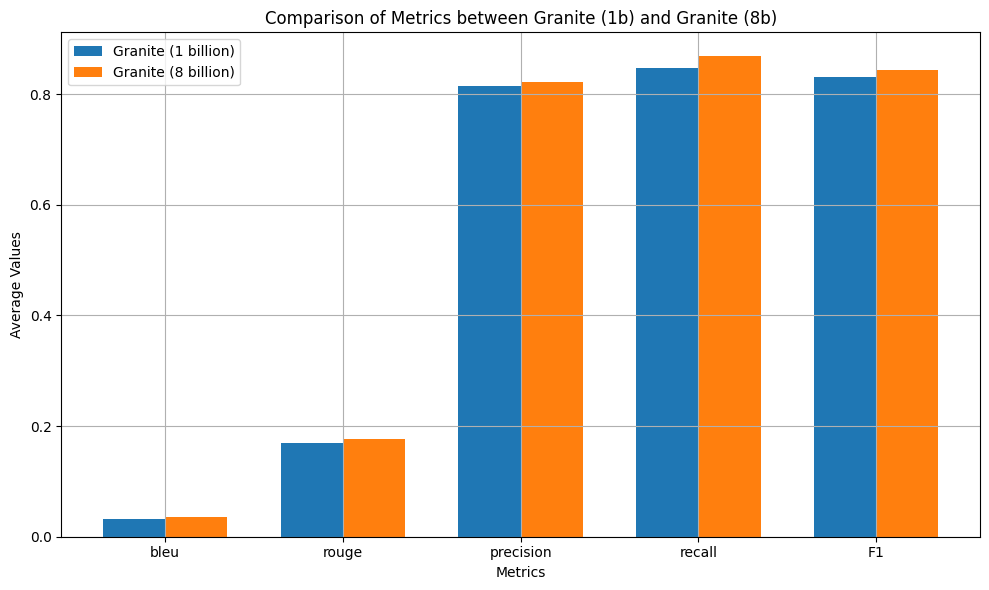

In [36]:
import numpy as np

metrics = ['bleu', 'rouge', 'precision', 'recall', 'F1']
results1_means = [results1[metric].apply(lambda x: x.item() if isinstance(x, pd.Series) else x).mean() for metric in metrics]
results2_means = [results2[metric].apply(lambda x: x.item() if isinstance(x, pd.Series) else x).mean() for metric in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, results1_means, width, label='Granite (1 billion)')
bars2 = ax.bar(x + width/2, results2_means, width, label='Granite (8 billion)')

ax.set_xlabel('Metrics')
ax.set_ylabel('Average Values')
ax.set_title('Comparison of Metrics between Granite (1b) and Granite (8b)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

plt.tight_layout()
plt.grid()
plt.show()

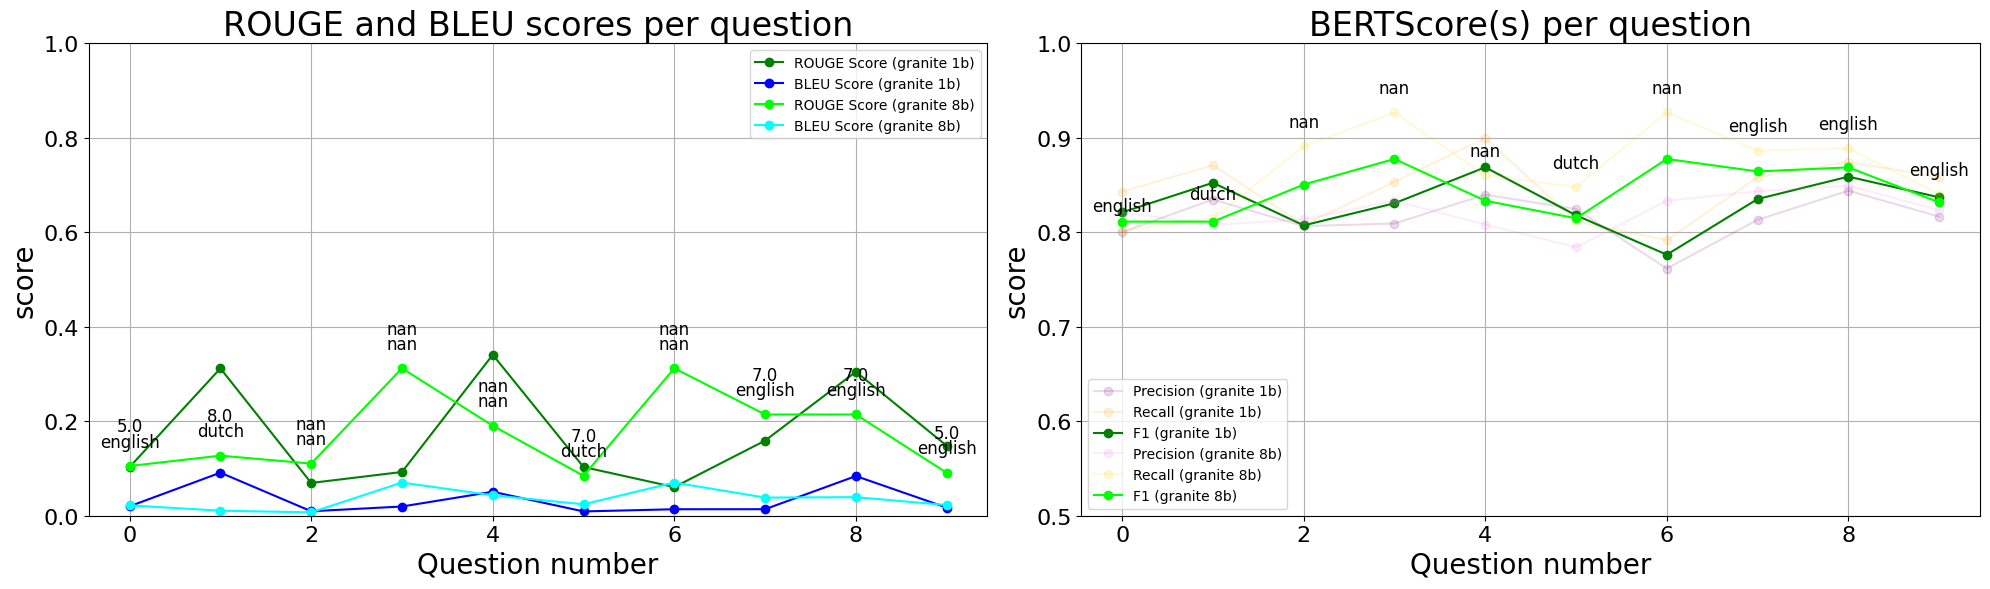

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Plot rouge and bleu scores for both results1 and results2
axes[0].plot(results1.index, results1['rouge'], marker='o', label='ROUGE Score (granite 1b)', color='green')
axes[0].plot(results1.index, results1['bleu'], marker='o', label='BLEU Score (granite 1b)', color='blue')
axes[0].plot(results2.index, results2['rouge'], marker='o', label='ROUGE Score (granite 8b)', color='lime')
axes[0].plot(results2.index, results2['bleu'], marker='o', label='BLEU Score (granite 8b)', color='cyan')
axes[0].set_title('ROUGE and BLEU scores per question', fontsize=24)
axes[0].set_xlabel('Question number', fontsize=20)
axes[0].tick_params(axis='x', labelsize=16)
axes[0].tick_params(axis='y', labelsize=16)
axes[0].set_ylabel('score', fontsize=20)
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(True)
for i, txt in enumerate(results2['original_language']):
  axes[0].annotate(txt, (results2.index[i], results2['rouge'][i]), textcoords="offset points", xytext=(0, 14), ha='center', fontsize=12)

for i, txt in enumerate(results2['specificity']):
  axes[0].annotate(txt, (results2.index[i], results2['rouge'][i]), textcoords="offset points", xytext=(0, 25), ha='center', fontsize=12)

# Plot precision, recall, and F1 scores for both results1 and results2
axes[1].plot(results1.index, results1['precision'], marker='o', label='Precision (granite 1b)', color='purple', alpha=0.15)
axes[1].plot(results1.index, results1['recall'], marker='o', label='Recall (granite 1b)', color='orange', alpha=0.15)
axes[1].plot(results1.index, results1['F1'], marker='o', label='F1 (granite 1b)', color='green')
axes[1].plot(results2.index, results2['precision'], marker='o', label='Precision (granite 8b)', color='violet', alpha=0.15)
axes[1].plot(results2.index, results2['recall'], marker='o', label='Recall (granite 8b)', color='gold', alpha=0.15)
axes[1].plot(results2.index, results2['F1'], marker='o', label='F1 (granite 8b)', color='lime')
axes[1].set_title('BERTScore(s) per question', fontsize=24)
axes[1].set_xlabel('Question number', fontsize=20)
axes[1].set_ylabel('score', fontsize=20)
axes[1].tick_params(axis='x', labelsize=16)
axes[1].tick_params(axis='y', labelsize=16)
axes[1].legend()
axes[1].grid(True)
axes[1].set_ylim(0.5, 1)
for i, txt in enumerate(results2['original_language']):
  axes[1].annotate(txt, (results2.index[i], results2['recall'][i]), textcoords="offset points", xytext=(0, 14), ha='center', fontsize=12)

plt.tight_layout()
plt.show()
